In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from matplotlib.cm import GnBu, viridis

import sys
sys.path.insert(0, '/projects/b1094/jding/athena/vis/python')
import athena_read
import glob


In [37]:
## Snapshots registration
#path = '/scratch/phn2956/disk-sph3/'
path = '/scratch/phn2956/disk-tilted/'
snapshot_list = sorted(glob.glob(path+'disk.out1.*.athdf'))


# Results for $t \lesssim 500$

loading snapshot at t=   0.0


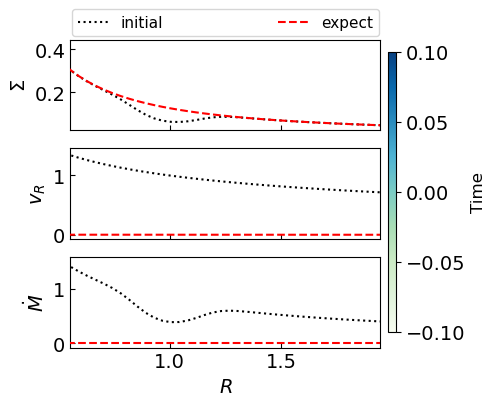

In [38]:
## Plot density, v_r, and Mdot
snapshot_plot = snapshot_list[0:1:1]


norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(3,1, figsize=(4,4),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1f']
    theta_app = ath_data['x2f']
    phi_app = ath_data['x3f']
    d_rad = rad_app[1]-rad_app[0]
    d_theta = theta_app[1]-theta_app[0]
    d_phi = phi_app[1]-phi_app[0]
    
    rad_app = (rad_app[1:]+rad_app[:-1])*0.5
    theta_app = (theta_app[1:]+theta_app[:-1])*0.5
    phi_app = (phi_app[1:]+phi_app[:-1])*0.5
    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velosity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    ## Sigma = surface integral of rho over a sphere (mass/dr) / (2pi*r)
    Sigma_integrand = den * rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    Sigma = np.sum(Sigma_integrand[:,:,2:-2],axis=(1,2))/(2*np.pi*rad_app)

    ## Mdot = surface integral of rho*vx1 over a sphere (mass/dr)
    Mdot_integrand = den*vx1 *rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    Mdot = np.sum(Mdot_integrand[:,:,2:-2],axis=(1,2))#/(2*np.pi*rad_app)

    ## mass-weighted v_R = Mdot / (2pi*r*Sigma)
    vr = Mdot / (Sigma * 2*np.pi*rad_app)
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'c': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'c': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'c': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs[0].plot(rad_app,Sigma,**kws)
    axs[1].plot(rad_app,vr,**kws)
    axs[2].plot(rad_app,Mdot,**kws)
    
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)


#### Add analytical solutions
Sigma_sol = Sigma[-1] * (rad_app/rad_app[-1])**-1.5
vR_sol    = vr[-1] * (rad_app/rad_app[-1])**0.5
Mdot_sol  = Mdot[-1] * (rad_app/rad_app[-1])**0
axs[0].plot(rad_app,Sigma_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[1].plot(rad_app,vR_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[2].plot(rad_app,Mdot_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[0].plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200,label='expect')

#### labels
axs[0].set_ylabel(r'$\Sigma$')
axs[1].set_ylabel(r'$v_{R}$')
axs[2].set_ylabel(r'$\dot{M}$')
axs[-1].set_xlabel(r'$R$')
axs[-1].set_xlim(rad_app[[3,-4]])

axs[0].legend(
    fontsize=11,
    loc='lower left',        
    bbox_to_anchor=(0., 1.02, 1., .102), 
    ncol=3,                  
    mode="expand",          
    borderaxespad=0.1       
)


for ax in axs.flatten():
    ax.tick_params(which='both',direction='in')


In [39]:
vx3[0]

array([[1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962],
       [1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962],
       [1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962],
       ...,
       [1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962],
       [1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962],
       [1.18920924, 1.52848924, 1.86768963, ..., 1.52848924, 1.86768963,
        2.20696962]])

## plot $\rho(\vec{r})$

In [57]:
len(phi_3d[0,0,:])

24

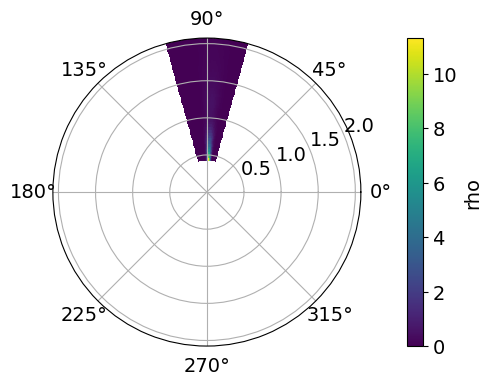

In [69]:
fig = plt.figure(figsize=(12,4))
#ax = fig.add_subplot()
ax = fig.add_subplot(projection='polar')

## view from above
theta_ind = 27 # 27 = midplane of domain
#c = ax.pcolormesh(phi_3d[:, theta_ind, :], rad_3d[:, theta_ind, :], den[:,theta_ind,:], cmap='viridis')

## view from the side
phi_ind = 2 # phi~0
c = ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], den[:,:,phi_ind], cmap='viridis')
phi_ind2 = 12 # phi~pi
#ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], den[:,:,phi_ind2], cmap='viridis')
#ax.set_thetalim(np.pi/2- .25, np.pi/2 + .25)

fig.colorbar(c, ax=ax, label="rho")

save_fig = False
if save_fig:
    plt.savefig("Figs/disk-side.png")

plt.show()

## print slopes of profiles

In [25]:
# indices of the two points we use to find the slope
i1 = 10
i2 = 35

slope = (np.log(Sigma[i2]) - np.log(Sigma[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Sigma slope=", np.round(slope,3))

vr_abs = np.abs(vr)
slope = (np.log(vr_abs[i2]) - np.log(vr_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("vr slope=", np.round(slope,3))

Mdot_abs = np.abs(Mdot)
slope = (np.log(Mdot_abs[i2]) - np.log(Mdot_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Mdot slope=", np.round(slope,3))

Sigma slope= -1.268
vr slope= -0.504
Mdot slope= -0.771


In [26]:
vr

array([ 1.28163741,  1.33460563,  1.38556303,  1.33796243,  1.29492969,
        1.25577805,  1.2199571 ,  1.18701983,  1.15659901,  1.12838978,
        1.10213643,  1.07762248,  1.05466317,  1.03310008,  1.01279677,
        0.99363506,  0.97551201,  0.95833754,  0.94203244,  0.92652645,
        0.91175646,  0.89766529,  0.88420149,  0.87131927,  0.85897787,
        0.84714057,  0.83577406,  0.82484796,  0.81433452,  0.80420835,
        0.79444619,  0.7850267 ,  0.77593022,  0.76713867,  0.75863533,
        0.75040475,  0.74243261,  0.73470562,  0.72721143,  0.71993854,
        0.71287623,  0.7060145 , -0.00192298, -0.00192553])